In [2]:
!pip install arabic-reshaper python-bidi groq dropbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.3/162.3 kB 11.8 MB/s eta 0:00:00


In [3]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import requests
from PIL import Image
from io import BytesIO
import arabic_reshaper
from bidi.algorithm import get_display
import textwrap
from math import ceil
import time

In [4]:
plt.set_cmap('gray')

<Figure size 640x480 with 0 Axes>

# Load Flickr8k images:

In [5]:
import glob
images_dirc = glob.glob('/kaggle/input/flickr8k/Images/*.jpg')
image_dict = {os.path.basename(path): path for path in images_dirc}

# Load Flickr8k captions

In [6]:
caption_df = pd.read_csv('/kaggle/input/arabic-captions-for-flickr8k-dataset/Flickr8k_arabic_text.txt', sep='\t', header=None, names=['image', 'caption'])
caption_df['image'] = caption_df['image'].apply(lambda x: x.split('#')[0])
caption_df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,طفلة صغيرة تتسلق إلى مسرح خشبي
1,1000268201_693b08cb0e.jpg,طفلة صغيرة تتسلق الدرج إلى منزلها
2,1000268201_693b08cb0e.jpg,فتاة صغيرة في ثوب وردي تذهب إلى المقصورة الخشبية
3,1001773457_577c3a7d70.jpg,كلب أسود وكلب ثلاثي الألوان يلعبان مع بعضهما ا...
4,1001773457_577c3a7d70.jpg,كلب أسود وكلب أبيض ببقع بنية يحدقان في بعضهما ...


In [7]:
caption_df.shape

(24274, 2)

# Remove duplicates

In [8]:
print("Before:", len(caption_df))
print("Unique images:", caption_df['image'].nunique())

Before: 24274
Unique images: 8092


In [9]:
# Remove duplicates first
caption_df = caption_df.drop_duplicates(subset=['image']).reset_index(drop=True)
caption_df.shape

(8092, 2)

# Display some images

In [10]:
sample_df = caption_df.sample(8, random_state=42)

# Step 3: Load the corresponding images
images = [plt.imread(image_dict[img]) for img in sample_df['image']]
captions = sample_df['caption'].tolist()

In [11]:
def show(images, captions, max_chars=40):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

    if n == 1:
        axes = [axes]

    for ax, img, caption in zip(axes, images, captions):
        ax.imshow(img)
        ax.axis("off")
        
        # Reshape and fix Arabic text
        reshaped_text = arabic_reshaper.reshape(caption)
        bidi_text = get_display(reshaped_text)
        
        # Wrap long text into multiple lines
        wrapped_lines = textwrap.wrap(bidi_text, max_chars)
        
        # Reverse the order of lines so they show correctly
        wrapped = "\n".join(reversed(wrapped_lines))
        
        # Place caption under the image
        ax.set_title(wrapped, fontsize=12, fontname="Arial", pad=20)

    plt.tight_layout()
    plt.show()


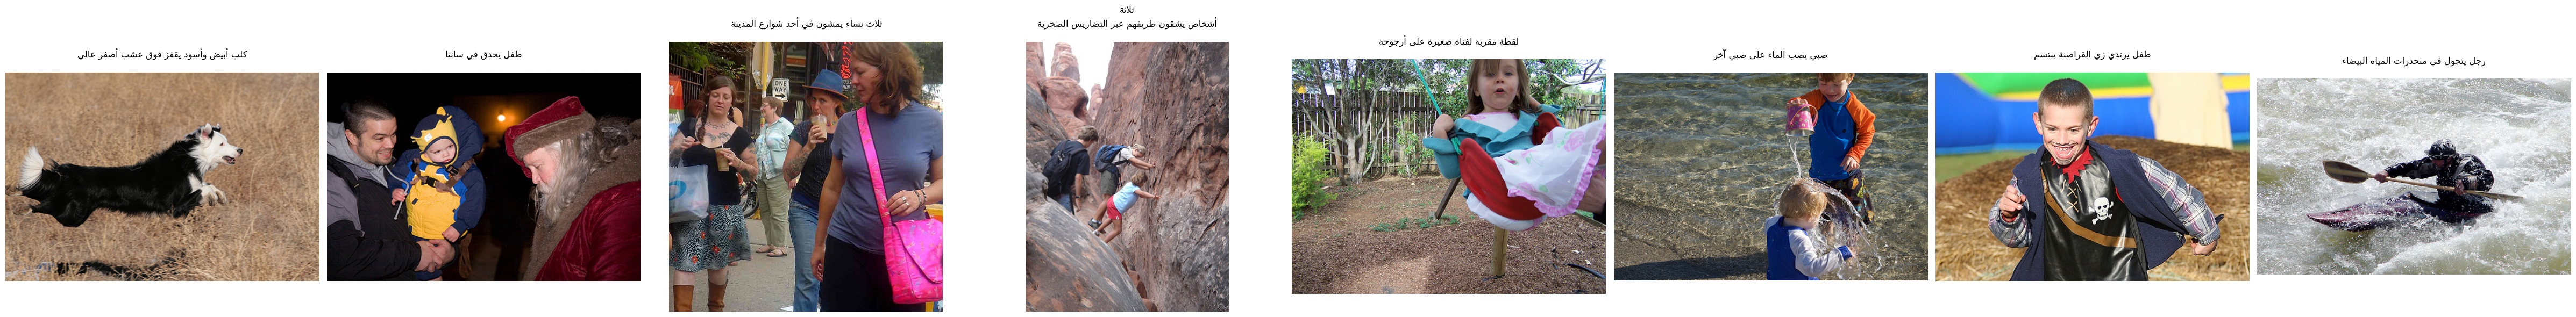

In [12]:
show(images, captions)

# Llama Model

In [13]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
key = user_secrets.get_secret("b_groq_key")

In [14]:
from groq import Groq, types

# Initialize client once
client = Groq(api_key=key)

def llama_caption(image_url, prompt="صف الصورة في جملة قصيرة"):

    completion = client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        messages=[
            {"role": "system", "content": "أجب فقط باللغة العربية الفصحى."},
            {"role": "user", "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": image_url}}
            ]}
        ],
        max_completion_tokens=256,
        temperature=0.7,
    )
    return completion.choices[0].message.content



## Split images for days

In [ ]:
total_images = len(images)
images_per_day = 300  # customize this
num_days = ceil(total_images / images_per_day)

# --- Set your current day ---
current_day = 4  # change this each day: 1, 2, 3, ...
start_idx = (current_day - 1) * images_per_day
end_idx = start_idx + images_per_day
sample = images[start_idx:]
print(f'number of days: {num_days} \n started from : {start_idx}, to :{end_idx}\n total images :{total_images}')

number of days: 4 
 started from : 900, to :1200
 total images :1192


# Generate captions

In [18]:
captions_gen = []
failed = []

In [ ]:
for img in sample:
    img_name = img.split("/")[-1].split("?")[0]
    try:
        # Generate caption using Llama-4 Scout
        caption = llama_caption(img)
        captions_gen.append((img_name, caption))
        print(f"[SUCCESS] Caption generated for {img_name}: {caption}")
    except Exception as e:
        failed.append(img_name)
        print(f"[ERROR] Failed on {img_name}: {e}")
    
    # Respect API rate limits
    time.sleep(0.5)

[SUCCESS] Caption generated for 2178306830_6af49375b4.jpg: غوص تحت الماء.
[SUCCESS] Caption generated for 217838128_1f0a84ddc1.jpg: رجل يصطاد في قارب على بحيرة هادئة.
[SUCCESS] Caption generated for 2180356743_b3a3c9a7f6.jpg: صورة لطفلين يلعبون كرة القدم في ساحة المدرسة.
[SUCCESS] Caption generated for 2180480870_dcaf5ac0df.jpg: كلب يجري في الحديقة.
[SUCCESS] Caption generated for 2180886307_5156460b2c.jpg: رجل يغوص في الماء.
[SUCCESS] Caption generated for 2181117039_c4eea8036e.jpg: صورة لطفلين يركضان في ساحة بينما يطير الحمام من حولهما.
[SUCCESS] Caption generated for 2181724497_dbb7fcb0a9.jpg: طفلة صغيرة في مقعد طعام، ترتدي ملابس حمراء وقد تلطخت أثناء تناول الطعام.
[SUCCESS] Caption generated for 2182050469_1edac0bc60.jpg: صورة لشاب يركب دراجته على رصيف خشبي طويل يمتد في بحيرة هادئة تحيط بها جبال خضراء.
[SUCCESS] Caption generated for 2182488373_df73c7cc09.jpg: الصورة لامرأتين في وسط المدينة، تحمل كل واحدة منهما شنطة.
[SUCCESS] Caption generated for 2183227136_8bb657846b.jpg: صورة ل

# Save captions 

In [ ]:
# --- Save today’s results ---
output_path = f"Data/Llama_captions/Llama_captions_day{current_day}.csv"
pd.DataFrame(captions_gen, columns=["image", "caption"]).to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Failed: {len(failed)} images")

Saved: /kaggle/working/Llama_captions_day4.csv
Failed: 0 images
